# Bridge Method Comparison

Compare bridge hydraulic method selections with a real HEC-RAS bridge example and show the effect on computed WSE.

In [1]:
#!pip install --upgrade ras-commander

## Development Mode

Set `USE_LOCAL_SOURCE = True` when running from a local ras-commander checkout. The committed default uses the installed package; repository test execution can still use local source through `PYTHONPATH`.

In [2]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = False

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path

    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: loading from {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE: loading installed ras-commander")

from pathlib import Path
import os
import shutil
import time
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ras_commander import RasCmdr, RasExamples, init_ras_project
from ras_commander.geom import GeomBridge
from ras_commander.hdf import HdfResultsXsec

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.ERROR)

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)

print("Imports complete")

PIP PACKAGE MODE: loading installed ras-commander


Imports complete


## Parameters

The workflow uses the `Bridge Hydraulics` example project because it includes one bridge with existing low-flow and pressure/weir method records. HEC-RAS 7.0 is used for execution so plan HDF results are available for extraction.

In [3]:
PROJECT_NAME = "Bridge Hydraulics"
RAS_EXE = Path(os.environ.get(
    "HECRAS_EXE",
    r"C:/Program Files (x86)/HEC/HEC-RAS/7.0/Ras.exe",
))

cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "ras_commander").exists() else cwd.parent
WORK_ROOT = Path(os.environ.get(
    "RAS_COMMANDER_WORKDIR",
    REPO_ROOT / "working" / "bridge_method_comparison",
))

BRIDGE_STATION = 5.4
PROFILE_HALF_WINDOW = 10
PLAN_NUMBER = "03"
NUM_CORES = 1

LOW_FLOW_SCENARIOS = [
    {"label": "Baseline", "low_flow_method": None},
    {"label": "Energy", "low_flow_method": "energy"},
    {"label": "Momentum", "low_flow_method": "momentum", "momentum_cd": 2.0},
    {"label": "Yarnell", "low_flow_method": "yarnell", "yarnell_k": 1.25},
]

WEIR_COEFFICIENTS = [2.6, 2.9, 3.1, 3.5, 4.0]
PRESSURE_FLOW_CDS = {
    "pressure_flow_submerged_inlet_cd": 0.4,
    "pressure_flow_submerged_inlet_outlet_cd": 0.8,
}

if not RAS_EXE.exists():
    raise FileNotFoundError(f"HEC-RAS executable not found: {RAS_EXE}")

WORK_ROOT.mkdir(parents=True, exist_ok=True)
print(f"HEC-RAS executable: {RAS_EXE}")
print(f"Working folder: {WORK_ROOT}")

HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe
Working folder: C:\GH\symphony-workspaces\ras-commander\CLB-304\working\bridge_method_comparison


## Helpers

In [4]:
def _safe_suffix(value):
    return str(value).lower().replace(" ", "_").replace(".", "_").replace("-", "_")


def extract_clean_project(suffix):
    target = WORK_ROOT / f"{PROJECT_NAME}_{suffix}"
    if target.exists():
        shutil.rmtree(target)
    return RasExamples.extract_project(PROJECT_NAME, output_path=WORK_ROOT, suffix=suffix)


def initialize_bridge_project(project_path):
    ras_obj = init_ras_project(project_path, str(RAS_EXE), load_results_summary=False)
    plan = str(ras_obj.plan_df.iloc[0]["plan_number"])
    geom_file = Path(ras_obj.plan_df.iloc[0]["Geom Path"])
    bridge = GeomBridge.get_bridges(geom_file).iloc[0]
    return ras_obj, plan, geom_file, bridge


def extract_wse_dataset(plan, ras_obj):
    ds = HdfResultsXsec.get_xsec_timeseries(plan, ras_object=ras_obj)
    stations = np.array([float(str(value).replace("*", "")) for value in ds["Station"].values])
    return ds, stations


def profile_window_indices(stations, bridge_station=BRIDGE_STATION, half_window=PROFILE_HALF_WINDOW):
    nearest_idx = int(np.argmin(np.abs(stations - bridge_station)))
    start = max(0, nearest_idx - half_window)
    stop = min(len(stations), nearest_idx + half_window + 1)
    return np.arange(start, stop)


def run_scenario(label, *, suffix, low_flow_method=None, high_flow_method=None,
                 momentum_cd=None, yarnell_k=None, weir_coefficient=None,
                 pressure_flow_submerged_inlet_cd=None,
                 pressure_flow_submerged_inlet_outlet_cd=None):
    project_path = extract_clean_project(suffix)
    ras_obj, plan, geom_file, bridge = initialize_bridge_project(project_path)

    before = GeomBridge.get_hydraulic_methods(
        geom_file,
        bridge["River"],
        bridge["Reach"],
        str(bridge["RS"]),
    )

    should_edit = any(value is not None for value in [
        low_flow_method,
        high_flow_method,
        momentum_cd,
        yarnell_k,
        weir_coefficient,
        pressure_flow_submerged_inlet_cd,
        pressure_flow_submerged_inlet_outlet_cd,
    ])

    edit_result = None
    if should_edit:
        edit_result = GeomBridge.set_hydraulic_methods(
            geom_file,
            bridge["River"],
            bridge["Reach"],
            str(bridge["RS"]),
            low_flow_method=low_flow_method,
            high_flow_method=high_flow_method,
            momentum_cd=momentum_cd,
            yarnell_k=yarnell_k,
            pressure_flow_submerged_inlet_cd=pressure_flow_submerged_inlet_cd,
            pressure_flow_submerged_inlet_outlet_cd=pressure_flow_submerged_inlet_outlet_cd,
            weir_coefficient=weir_coefficient,
            create_backup=False,
        )

    started = time.perf_counter()
    compute_result = RasCmdr.compute_plan(
        plan,
        ras_object=ras_obj,
        force_geompre=True,
        force_rerun=True,
        num_cores=NUM_CORES,
        verify=False,
    )
    runtime_sec = time.perf_counter() - started
    if not compute_result:
        raise RuntimeError(f"HEC-RAS compute failed for scenario {label}")

    ds, stations = extract_wse_dataset(plan, ras_obj)
    after = GeomBridge.get_hydraulic_methods(
        geom_file,
        bridge["River"],
        bridge["Reach"],
        str(bridge["RS"]),
    )

    return {
        "label": label,
        "suffix": suffix,
        "project_path": project_path,
        "plan": plan,
        "geom_file": geom_file,
        "bridge": bridge,
        "before": before,
        "after": after,
        "edit_result": edit_result,
        "compute_result": compute_result,
        "runtime_sec": runtime_sec,
        "dataset": ds,
        "stations": stations,
    }


def dataset_profile_frame(result, time_index, window_indices):
    ds = result["dataset"]
    wse = ds["Water_Surface"].isel(time=time_index, cross_section=window_indices).values
    return pd.DataFrame({
        "Scenario": result["label"],
        "Station": [str(value) for value in ds["Station"].values[window_indices]],
        "StationNum": result["stations"][window_indices],
        "WSE": wse.astype(float),
    })

print("Helper functions ready")

Helper functions ready


## Baseline And Low-Flow Method Runs

The baseline preserves the example project's existing method settings. The comparison runs set the same bridge to Energy, Momentum, and Yarnell low-flow methods while keeping pressure/weir high-flow handling enabled.

In [5]:
method_results = []

for config in LOW_FLOW_SCENARIOS:
    label = config["label"]
    suffix = f"method_{_safe_suffix(label)}"
    kwargs = {key: value for key, value in config.items() if key != "label"}
    if label != "Baseline":
        kwargs["high_flow_method"] = "pressure_weir"
    result = run_scenario(label, suffix=suffix, **kwargs)
    method_results.append(result)
    print(
        f"{label:8s} | low={result['after']['low_flow_method']:<8s} "
        f"high={result['after']['high_flow_method']:<13s} "
        f"runtime={result['runtime_sec']:.1f}s"
    )

baseline = method_results[0]
bridge = baseline["bridge"]
print("\nBridge:")
display(pd.DataFrame([{
    "River": bridge["River"],
    "Reach": bridge["Reach"],
    "RS": bridge["RS"],
    "Baseline Low Flow": baseline["before"]["low_flow_method"],
    "Baseline High Flow": baseline["before"]["high_flow_method"],
    "Deck/Weir Coefficient": baseline["before"]["coefficients"]["weir_coefficient"],
}]))

Baseline | low=momentum high=pressure_weir runtime=11.1s


Energy   | low=energy   high=pressure_weir runtime=11.2s


Momentum | low=momentum high=pressure_weir runtime=11.9s


Yarnell  | low=yarnell  high=pressure_weir runtime=11.3s

Bridge:


,River,Reach,RS,Baseline Low Flow,Baseline High Flow,Deck/Weir Coefficient
0,Beaver Creek,Kentwood,5.4,momentum,pressure_weir,2.6


## Truncated WSE Profile Near The Bridge

The plotted time step is selected from the computed results: it is the time where Energy, Momentum, and Yarnell produce the largest WSE spread within the bridge-centered profile window.

In [6]:
stations = baseline["stations"]
window_indices = profile_window_indices(stations)
comparison_labels = ["Energy", "Momentum", "Yarnell"]
comparison_results = [result for result in method_results if result["label"] in comparison_labels]

stack = np.stack([
    result["dataset"]["Water_Surface"].isel(cross_section=window_indices).values
    for result in comparison_results
])
spread = np.nanmax(stack, axis=0) - np.nanmin(stack, axis=0)
time_index, local_xs_index = np.unravel_index(np.nanargmax(spread), spread.shape)
profile_time = pd.Timestamp(str(baseline["dataset"]["time"].values[time_index]))
max_spread = float(spread[time_index, local_xs_index])

profile_df = pd.concat([
    dataset_profile_frame(result, time_index, window_indices)
    for result in method_results
], ignore_index=True)

print(f"Selected profile time: {profile_time}")
print(f"Maximum method WSE spread in plotted window: {max_spread:.3f} ft")

pivot = profile_df.pivot_table(
    index=["Station", "StationNum"],
    columns="Scenario",
    values="WSE",
).reset_index()
display(pivot.round(3))

Selected profile time: 1990-02-10 19:00:00
Maximum method WSE spread in plotted window: 0.602 ft


Scenario,Station,StationNum,Baseline,Energy,Momentum,Yarnell
0,5.226,5.226,213.609,213.609,213.609,213.617
1,5.242,5.242,213.730,213.730,213.730,213.738
2,5.258,5.258,213.840,213.840,213.840,213.848
3,5.274,5.274,213.940,213.940,213.940,213.948
4,5.29,5.290,214.032,214.032,214.032,214.040
...,...,...,...,...,...,...
16,5.508,5.508,216.086,216.086,216.086,215.721
17,5.525,5.525,216.126,216.126,216.126,215.775
18,5.542,5.542,216.173,216.173,216.173,215.838
19,5.559,5.559,216.220,216.220,216.220,215.900


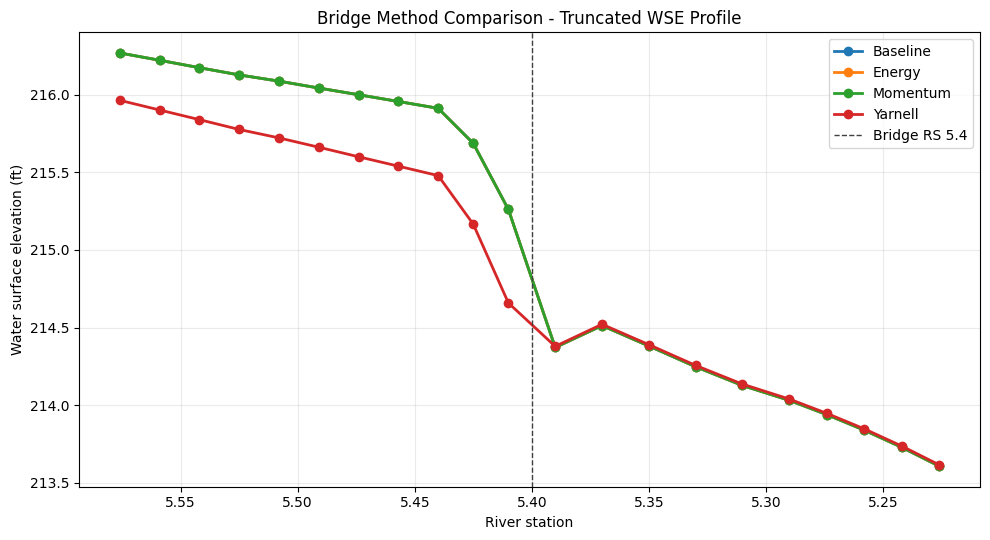

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for label, group in profile_df.groupby("Scenario", sort=False):
    ax.plot(group["StationNum"], group["WSE"], marker="o", linewidth=2, label=label)

ax.axvline(BRIDGE_STATION, color="0.25", linestyle="--", linewidth=1, label="Bridge RS 5.4")
ax.invert_xaxis()
ax.set_xlabel("River station")
ax.set_ylabel("Water surface elevation (ft)")
ax.set_title("Bridge Method Comparison - Truncated WSE Profile")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## Pressure/Weir Coefficient Sensitivity

The pressure/weir run keeps the low-flow method fixed at Energy, sets pressure-flow coefficients, and varies the bridge deck/weir coefficient over broad-crested through ogee-style values. The response metric is maximum WSE at the bridge upstream face cross section nearest RS 5.41.

In [8]:
weir_results = []
weir_rows = []

for coeff in WEIR_COEFFICIENTS:
    label = f"Cd {coeff:g}"
    result = run_scenario(
        label,
        suffix=f"weir_{_safe_suffix(coeff)}",
        low_flow_method="energy",
        high_flow_method="pressure_weir",
        weir_coefficient=coeff,
        **PRESSURE_FLOW_CDS,
    )
    weir_results.append(result)

    ds = result["dataset"]
    stations = result["stations"]
    bridge_face_idx = int(np.argmin(np.abs(stations - 5.41)))
    max_wse_at_bridge = float(ds["Water_Surface"].isel(cross_section=bridge_face_idx).max().values)
    peak_time_idx = int(ds["Water_Surface"].isel(cross_section=bridge_face_idx).argmax().values)
    peak_time = pd.Timestamp(str(ds["time"].values[peak_time_idx]))
    weir_rows.append({
        "Weir Coefficient": coeff,
        "Nearest Station": str(ds["Station"].values[bridge_face_idx]),
        "Peak Time": peak_time,
        "Max WSE At Bridge (ft)": max_wse_at_bridge,
        "Deck Line After": result["edit_result"]["deck_line_after"],
    })
    print(
        f"Cd={coeff:g} | WSE={max_wse_at_bridge:.3f} ft | "
        f"runtime={result['runtime_sec']:.1f}s"
    )

weir_df = pd.DataFrame(weir_rows)
display(weir_df[["Weir Coefficient", "Nearest Station", "Peak Time", "Max WSE At Bridge (ft)"]].round(3))

Cd=2.6 | WSE=217.150 ft | runtime=11.1s


Cd=2.9 | WSE=217.124 ft | runtime=11.3s


Cd=3.1 | WSE=217.103 ft | runtime=11.1s


Cd=3.5 | WSE=217.096 ft | runtime=11.0s


Cd=4 | WSE=217.048 ft | runtime=10.8s


,Weir Coefficient,Nearest Station,Peak Time,Max WSE At Bridge (ft)
0,2.6,5.41,1990-02-11 05:00:00,217.150
1,2.9,5.41,1990-02-11 05:00:00,217.124
2,3.1,5.41,1990-02-11 05:00:00,217.103
3,3.5,5.41,1990-02-11 05:00:00,217.096
4,4.0,5.41,1990-02-11 05:00:00,217.048


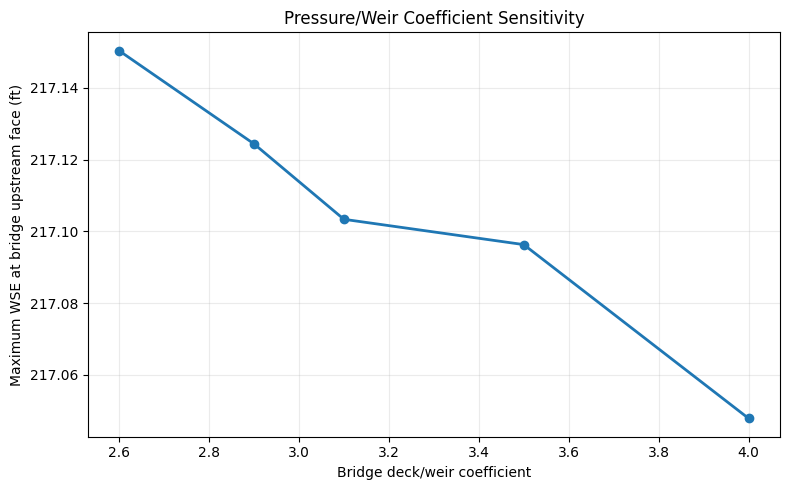

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    weir_df["Weir Coefficient"],
    weir_df["Max WSE At Bridge (ft)"],
    marker="o",
    linewidth=2,
    color="tab:blue",
)
ax.set_xlabel("Bridge deck/weir coefficient")
ax.set_ylabel("Maximum WSE at bridge upstream face (ft)")
ax.set_title("Pressure/Weir Coefficient Sensitivity")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## Summary

In [10]:
method_summary = []
base_profile = profile_df[profile_df["Scenario"] == "Baseline"][["StationNum", "WSE"]].rename(columns={"WSE": "Baseline WSE"})
for label in ["Energy", "Momentum", "Yarnell"]:
    scenario = profile_df[profile_df["Scenario"] == label][["StationNum", "WSE"]]
    joined = scenario.merge(base_profile, on="StationNum")
    diff = joined["WSE"] - joined["Baseline WSE"]
    method_summary.append({
        "Scenario": label,
        "Min Delta vs Baseline (ft)": float(diff.min()),
        "Max Delta vs Baseline (ft)": float(diff.max()),
        "Max Abs Delta (ft)": float(diff.abs().max()),
    })

summary_df = pd.DataFrame(method_summary)
weir_delta = float(
    weir_df["Max WSE At Bridge (ft)"].max() - weir_df["Max WSE At Bridge (ft)"].min()
)

print("Low-flow method WSE differences in plotted bridge window:")
display(summary_df.round(3))
print(f"Weir coefficient sweep WSE range at bridge: {weir_delta:.3f} ft")

Low-flow method WSE differences in plotted bridge window:


,Scenario,Min Delta vs Baseline (ft),Max Delta vs Baseline (ft),Max Abs Delta (ft)
0,Energy,0.000,0.000,0.000
1,Momentum,0.000,0.000,0.000
2,Yarnell,-0.602,0.009,0.602


Weir coefficient sweep WSE range at bridge: 0.102 ft
